In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Carpeta del proyecto:", PROJECT_ROOT)
print("Ruta del dataset:", DATA_PATH)
print("¿Existe el archivo?:", DATA_PATH.exists())

Carpeta del proyecto: c:\Users\vfuen\Documents\telco-customer-churn-mle2
Ruta del dataset: c:\Users\vfuen\Documents\telco-customer-churn-mle2\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
¿Existe el archivo?: True


In [3]:
df_original = pd.read_csv(DATA_PATH)

print("Cantidad de filas:", df_original.shape[0])
print("Cantidad de columnas:", df_original.shape[1])

df_original.head()

Cantidad de filas: 7043
Cantidad de columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Nombres de las columnas:")
print(df_original.columns.tolist())

print("\nInformación general:")
df_original.info()

Nombres de las columnas:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecur

In [5]:
print("Filas duplicadas:", df_original.duplicated().sum())
print("Clientes únicos:", df_original["customerID"].nunique())
print(
    "Espacios vacíos en TotalCharges:",
    df_original["TotalCharges"].astype(str).str.strip().eq("").sum()
)

print("\nDistribución de Churn:")
display(df_original["Churn"].value_counts())

print("\nDistribución porcentual:")
display(
    df_original["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Filas duplicadas: 0
Clientes únicos: 7043
Espacios vacíos en TotalCharges: 11

Distribución de Churn:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Distribución porcentual:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 2. Limpieza y transformación de datos

Se crea una copia del dataset original para preservar los datos sin modificaciones.
Se corrige la variable `TotalCharges`, se eliminan registros incompletos y se
transforma la variable objetivo `Churn` a formato binario.

In [6]:
filtro_totalcharges_vacio = (
    df_original["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
)

columnas_revision = [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn",
]

df_original.loc[
    filtro_totalcharges_vacio,
    columnas_revision
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
df_limpio = df_original.copy()

# Convertir TotalCharges desde texto a número.
# Los espacios vacíos se transforman en valores faltantes.
df_limpio["TotalCharges"] = pd.to_numeric(
    df_limpio["TotalCharges"],
    errors="coerce"
)

# Transformar la variable objetivo a formato binario.
df_limpio["Churn"] = df_limpio["Churn"].map(
    {"No": 0, "Yes": 1}
)

# Convertir SeniorCitizen en una variable categórica comprensible.
df_limpio["SeniorCitizen"] = df_limpio["SeniorCitizen"].map(
    {0: "No", 1: "Yes"}
)

# Eliminar los 11 registros sin TotalCharges.
df_limpio = (
    df_limpio
    .dropna(subset=["TotalCharges"])
    .reset_index(drop=True)
)

print("Filas originales:", len(df_original))
print("Filas después de la limpieza:", len(df_limpio))
print("Valores faltantes totales:", df_limpio.isna().sum().sum())

Filas originales: 7043
Filas después de la limpieza: 7032
Valores faltantes totales: 0


In [8]:
print("Tipo de TotalCharges:", df_limpio["TotalCharges"].dtype)
print("Valores de Churn:", sorted(df_limpio["Churn"].unique()))
print("Valores de SeniorCitizen:", df_limpio["SeniorCitizen"].unique())

display(df_limpio.head())

Tipo de TotalCharges: float64
Valores de Churn: [np.int64(0), np.int64(1)]
Valores de SeniorCitizen: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [9]:
PROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "telco_churn_limpio.csv"
)

df_limpio.to_csv(
    PROCESSED_PATH,
    index=False
)

print("Base procesada guardada en:")
print(PROCESSED_PATH)
print("¿Existe el archivo?:", PROCESSED_PATH.exists())

Base procesada guardada en:
c:\Users\vfuen\Documents\telco-customer-churn-mle2\data\processed\telco_churn_limpio.csv
¿Existe el archivo?: True


## 3. Análisis exploratorio de datos

En esta sección se analiza la distribución de la variable objetivo y su relación
con las principales características de los clientes.

In [10]:
variables_numericas = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

resumen_numerico = (
    df_limpio[variables_numericas]
    .describe()
    .round(2)
)

display(resumen_numerico)

,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


El resumen numérico está correcto. Ya podemos registrar estos primeros hallazgos:

La base limpia contiene 7.032 clientes.
La antigüedad promedio es de 32,42 meses.
La mediana de antigüedad es de 29 meses.
El cargo mensual promedio es de 64,80.
El cargo total promedio es de 2.283,30.
TotalCharges tiene bastante dispersión, porque algunos clientes son nuevos y otros llevan hasta 72 meses.

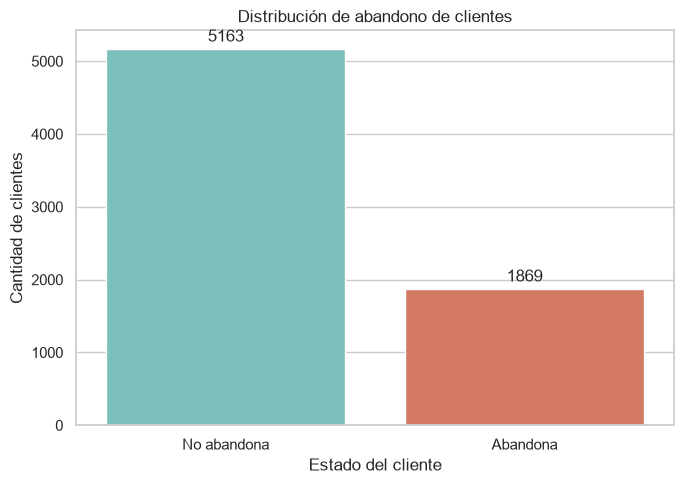

In [11]:
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

conteo_churn = (
    df_limpio["Churn"]
    .value_counts()
    .reindex([0, 1])
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=["No abandona", "Abandona"],
    y=conteo_churn.values,
    hue=["No abandona", "Abandona"],
    palette=["#6FCAC4", "#E76F51"],
    legend=False,
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Distribución de abandono de clientes")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "01_distribucion_churn.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,Contract,TasaChurn
0,Month-to-month,42.709677
1,One year,11.277174
2,Two year,2.848665


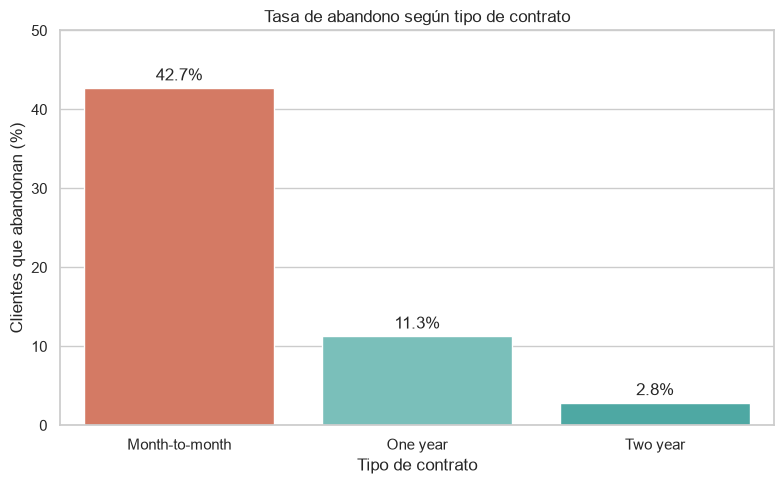

In [12]:
tasa_churn_contrato = (
    df_limpio
    .groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="TasaChurn")
)

display(tasa_churn_contrato)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tasa_churn_contrato,
    x="Contract",
    y="TasaChurn",
    hue="Contract",
    palette=["#E76F51", "#6FCAC4", "#3FB7B0"],
    legend=False,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

plt.title("Tasa de abandono según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Clientes que abandonan (%)")
plt.ylim(0, 50)
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "02_churn_por_contrato.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretación del tipo de contrato

Los clientes con contrato mensual presentan una tasa de abandono de 42,7%,
mientras que esta disminuye a 11,3% en contratos de un año y a 2,8% en
contratos de dos años. Por tanto, el tipo de contrato podría ser uno de los
predictores más relevantes del modelo.

In [13]:
comparacion_numerica = (
    df_limpio
    .groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ]
    .mean()
    .round(2)
    .rename(
        index={
            0: "No abandona",
            1: "Abandona",
        }
    )
)

display(comparacion_numerica)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No abandona,37.65,61.31,2555.34
Abandona,17.98,74.44,1531.80


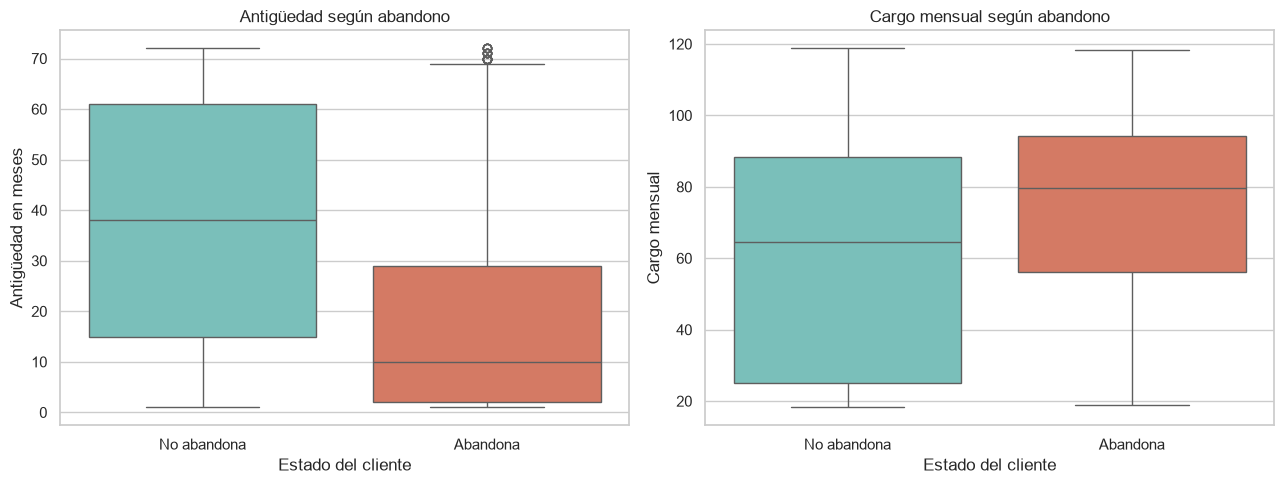

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

sns.boxplot(
    data=df_limpio,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette=["#6FCAC4", "#E76F51"],
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Antigüedad según abandono")
axes[0].set_xlabel("Estado del cliente")
axes[0].set_ylabel("Antigüedad en meses")
axes[0].set_xticks([0, 1], ["No abandona", "Abandona"])

sns.boxplot(
    data=df_limpio,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette=["#6FCAC4", "#E76F51"],
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Cargo mensual según abandono")
axes[1].set_xlabel("Estado del cliente")
axes[1].set_ylabel("Cargo mensual")
axes[1].set_xticks([0, 1], ["No abandona", "Abandona"])

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "03_variables_numericas_por_churn.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretación de antigüedad y cargos

Los clientes que abandonan presentan una antigüedad menor que quienes
permanecen. También muestran cargos mensuales más elevados. Estos resultados
sugieren que los clientes nuevos y con mayores pagos mensuales podrían tener
una mayor probabilidad de abandono. Estas relaciones serán posteriormente
evaluadas mediante los modelos de clasificación.

In [15]:
tasa_internet = (
    df_limpio
    .groupby("InternetService")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="TasaChurn")
)

tasa_pago = (
    df_limpio
    .groupby("PaymentMethod")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="TasaChurn")
)

display(tasa_internet)
display(tasa_pago)

,InternetService,TasaChurn
0,Fiber optic,41.892765
1,DSL,18.998344
2,No,7.434211


,PaymentMethod,TasaChurn
0,Electronic check,45.285412
1,Mailed check,19.201995
2,Bank transfer (automatic),16.731518
3,Credit card (automatic),15.253123


### Interpretación del servicio y método de pago

Los clientes con servicio de fibra óptica presentan una tasa de abandono de
41,89%, superior a la observada en clientes con DSL o sin servicio de internet.
Asimismo, el pago mediante cheque electrónico alcanza una tasa de abandono de
45,29%, mientras que los métodos de pago automático presentan tasas cercanas
al 15%-17%.

Estos resultados muestran asociaciones relevantes para la predicción, pero no
permiten concluir que el servicio o el método de pago causen directamente el
abandono.

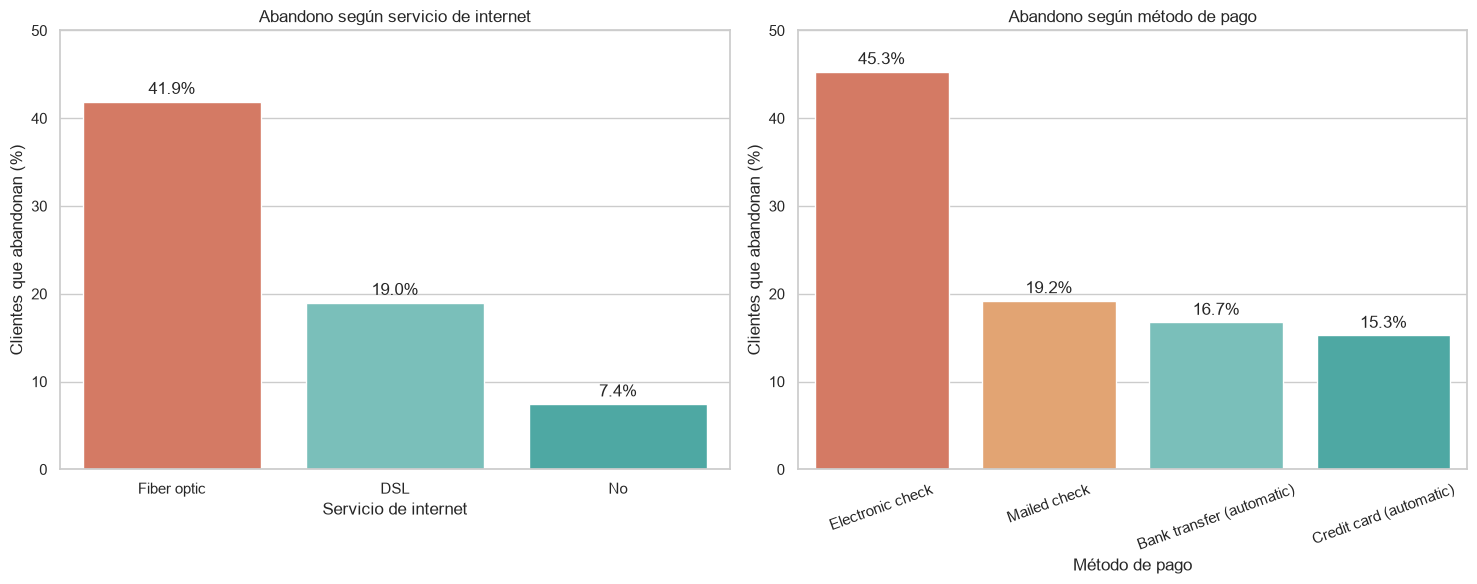

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

sns.barplot(
    data=tasa_internet,
    x="InternetService",
    y="TasaChurn",
    hue="InternetService",
    palette=["#E76F51", "#6FCAC4", "#3FB7B0"],
    legend=False,
    ax=axes[0],
)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

axes[0].set_title("Abandono según servicio de internet")
axes[0].set_xlabel("Servicio de internet")
axes[0].set_ylabel("Clientes que abandonan (%)")
axes[0].set_ylim(0, 50)

sns.barplot(
    data=tasa_pago,
    x="PaymentMethod",
    y="TasaChurn",
    hue="PaymentMethod",
    palette=["#E76F51", "#F4A261", "#6FCAC4", "#3FB7B0"],
    legend=False,
    ax=axes[1],
)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

axes[1].set_title("Abandono según método de pago")
axes[1].set_xlabel("Método de pago")
axes[1].set_ylabel("Clientes que abandonan (%)")
axes[1].set_ylim(0, 50)
axes[1].tick_params(
    axis="x",
    rotation=20,
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "04_churn_por_servicio_y_pago.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 4. División en entrenamiento, validación y prueba

La base se divide de forma estratificada para conservar la proporción de
abandono en todos los conjuntos:

- 70% para entrenamiento.
- 15% para validación.
- 15% para prueba final.

Se utiliza una semilla fija para garantizar que la división sea reproducible.

In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

df_train, df_temporal = train_test_split(
    df_limpio,
    test_size=0.30,
    stratify=df_limpio["Churn"],
    random_state=RANDOM_STATE,
)

df_validation, df_test = train_test_split(
    df_temporal,
    test_size=0.50,
    stratify=df_temporal["Churn"],
    random_state=RANDOM_STATE,
)

print("Entrenamiento:", df_train.shape)
print("Validación:", df_validation.shape)
print("Prueba:", df_test.shape)

Entrenamiento: (4922, 21)
Validación: (1055, 21)
Prueba: (1055, 21)


In [18]:
distribucion_conjuntos = pd.DataFrame(
    {
        "Conjunto": [
            "Entrenamiento",
            "Validación",
            "Prueba",
        ],
        "Registros": [
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "Churn_pct": [
            df_train["Churn"].mean() * 100,
            df_validation["Churn"].mean() * 100,
            df_test["Churn"].mean() * 100,
        ],
    }
)

distribucion_conjuntos["Churn_pct"] = (
    distribucion_conjuntos["Churn_pct"].round(2)
)

display(distribucion_conjuntos)

,Conjunto,Registros,Churn_pct
0,Entrenamiento,4922,26.57
1,Validación,1055,26.64
2,Prueba,1055,26.54


In [19]:
clientes_train = set(df_train["customerID"])
clientes_validation = set(df_validation["customerID"])
clientes_test = set(df_test["customerID"])

print(
    "Coincidencias TRAIN-VALIDATION:",
    len(clientes_train & clientes_validation),
)

print(
    "Coincidencias TRAIN-TEST:",
    len(clientes_train & clientes_test),
)

print(
    "Coincidencias VALIDATION-TEST:",
    len(clientes_validation & clientes_test),
)

Coincidencias TRAIN-VALIDATION: 0
Coincidencias TRAIN-TEST: 0
Coincidencias VALIDATION-TEST: 0


In [20]:
df_train.to_csv(
    PROJECT_ROOT / "data" / "processed" / "train.csv",
    index=False,
)

df_validation.to_csv(
    PROJECT_ROOT / "data" / "processed" / "validation.csv",
    index=False,
)

df_test.to_csv(
    PROJECT_ROOT / "data" / "processed" / "test.csv",
    index=False,
)

print("Conjuntos guardados correctamente.")

Conjuntos guardados correctamente.
